In [1]:
import netCDF4 as nc
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.path as mpath
import cartopy.feature as cfeature

import seaborn as sns
import matplotlib.colors as cols
from mpl_toolkits.basemap import Basemap

In [2]:
pwd

'/home/dell/iHESPplot/Paper3'

In [3]:
openocean = np.load('/home/dell/iHESPplot/SWMT/openoceandeep176runing.npy')
openoceantime = np.load('/home/dell/iHESPplot/SWMT/openoceandeeptime176runing.npy')

In [4]:
DSW1 = np.load('/home/dell/iHESPplot/iceplot/cross1000sigma1/weDSW1plusplusrun.npy')
DSW1time = np.load('/home/dell/iHESPplot/iceplot/cross1000sigma1/we2timeplusplusrun.npy')

In [5]:
WSPsmall = np.load('/home/dell/iHESPplot/iceplot/smallMRP.npy')
WSPbigger = np.load('/home/dell/iHESPplot/iceplot/smallWSP.npy')

In [6]:
openocean.shape

(246,)

In [7]:
pwd

'/home/dell/iHESPplot/Paper3'

In [8]:
SWMTs = np.load('/home/dell/iHESPplot/SWMT/SWMTsurface.npy')
SWMTsall = np.load('/home/dell/iHESPplot/SWMT/SWMTsurfacealltime.npy')

findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


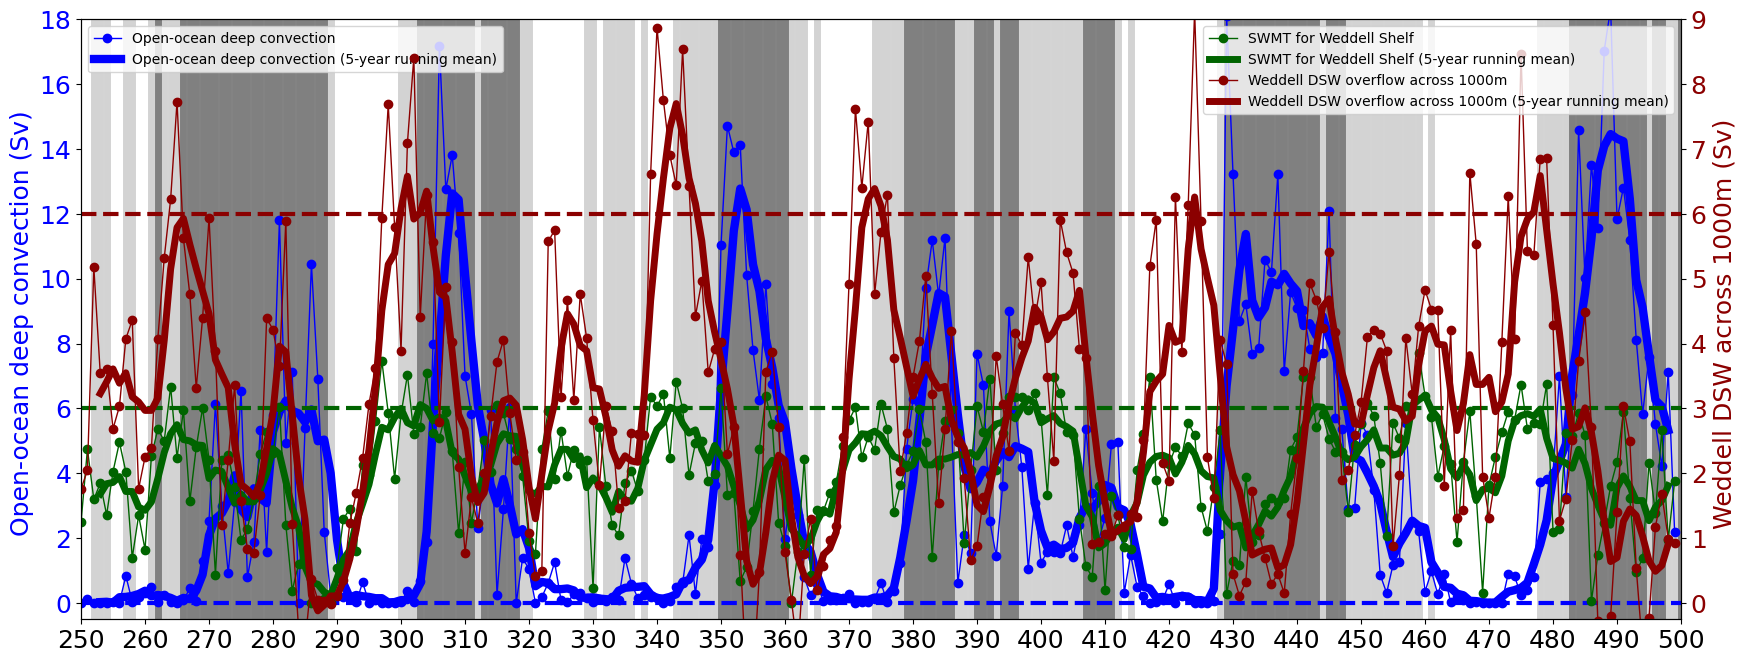

In [9]:
fig = plt.figure(figsize=(20,20), dpi=100)
my_font = {'fontname':'Cambria', 'size':'18'}
################################################################
################################################################
t = np.arange(3,249,1)
ax1 = fig.add_axes([0.1, 0.9, 0.8, 0.3],
                   xticklabels=[])
ax1.plot(openoceantime,color='blue',marker='o',linewidth=1,label='Open-ocean deep convection')

ax1.plot(t,openocean,color='blue',linewidth=6,label='Open-ocean deep convection (5-year running mean)')
plt.legend(loc='upper left')#,fontsize='xx-large')
#plt.legend()


plt.vlines(WSPsmall, -1, 20, linestyles="solid", colors="lightgrey" ,linewidth=5)
plt.vlines(WSPbigger, -1, 20, linestyles="solid", colors="grey" ,linewidth=5)
plt.hlines(0,0,250,linestyles="dashed", colors="blue",linewidth=3)
plt.axis("tight")
plt.yticks(np.arange(0,20,2), ['0','2','4','6','8','10','12','14', '16', '18'],**my_font,color='blue')
plt.ylabel('Open-ocean deep convection (Sv) ',**my_font,color='blue')
#plt.title('Weddell DSW overflow across 1000m isodepth ($\sigma$$_1$>32.58)',**my_font)
plt.xticks(np.arange(0,260,10), ['250','260','270','280','290','300','310','320','330','340','350','360','370','380','390','400','410','420','430','440','450','460','470','480','490','500'],**my_font)
ax1.set(ylim=(-0.5, 18),xlim=(0, 250))


#plt.vlines(49, -1, 20, linestyles="solid", colors="green" ,linewidth=3)

#plt.vlines(93, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(124, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(177, -1, 20, linestyles="solid", colors="green" ,linewidth=3)
#plt.vlines(228, -1, 20, linestyles="solid", colors="green" ,linewidth=3)

ax2 = ax1.twinx()

ax2.plot(SWMTsall,color='darkgreen',marker='o',linewidth=1,label='SWMT for Weddell Shelf')

ax2.plot(t,SWMTs,color='darkgreen',linewidth=5,label='SWMT for Weddell Shelf (5-year running mean)')

ax2.plot(DSW1time,color='darkred',marker='o',linewidth=1,label='Weddell DSW overflow across 1000m')

ax2.plot(t,DSW1,color='darkred',linewidth=5,label='Weddell DSW overflow across 1000m (5-year running mean)')



plt.legend(loc='upper right')#,fontsize='xx-large')
plt.yticks(np.arange(0,10,1), ['0','1','2','3','4','5','6','7','8','9'],**my_font,color='darkred')
plt.ylabel('Weddell DSW across 1000m (Sv) ',**my_font,color='darkred')
#plt.ylabel('Weddell DSW across  ',**my_font,color='darkred')
plt.hlines(6,0,250,linestyles="dashed", colors="darkred",linewidth=3)
plt.hlines(3, 0, 250, linestyles="dashed", colors="darkgreen" ,linewidth=3)
ax2.set(ylim=(-0.25, 9),xlim=(0, 250))

plt.savefig("Fig3.png",bbox_inches='tight')

In [10]:
import pandas as pd

data1 = openocean[:]
data2 = DSW1[:]
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
#print(df1)

In [11]:
def cross_corr(datax, datay, lag=0):
    """Calculate lagged cross correlation."""
    return datax.corr(datay.shift(lag))

In [12]:
monthly_cross_corrs = [cross_corr(df1[0], df2[0], lag=i) for i in range(10)]

In [13]:
monthly_cross_corrs2 = [cross_corr(df2[0], df1[0], lag=i) for i in range(10)]

In [14]:
monthly_cross_corrs

[-0.435504540394374,
 -0.34794842647107166,
 -0.24983715501864423,
 -0.1391874449219341,
 -0.017217373916328115,
 0.10522328576767835,
 0.21951693120616522,
 0.3234984832387051,
 0.4114949662036983,
 0.4746284945660166]

In [15]:
monthly_cross_corrs2

[-0.43550454039437403,
 -0.5078823310934206,
 -0.5600710936966559,
 -0.590856322140581,
 -0.5985577097394869,
 -0.5822002761871556,
 -0.5472318567729414,
 -0.4997628364047669,
 -0.4457313892097488,
 -0.38611749124925765]

In [16]:
import pandas as pd

data1 = SWMTs[:]
data2 = DSW1[:]
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
#print(df1)

In [17]:
def cross_corr(datax, datay, lag=0):
    """Calculate lagged cross correlation."""
    return datax.corr(datay.shift(lag))

In [18]:
monthly_cross_corrsQQ = [cross_corr(df1[0], df2[0], lag=i) for i in range(10)]

In [19]:
monthly_cross_corrsQQ2 = [cross_corr(df2[0], df1[0], lag=i) for i in range(10)]

In [20]:
monthly_cross_corrsQQ

[0.7589010507969646,
 0.6386255727012733,
 0.49364212038199834,
 0.33807195085610453,
 0.1864604082610728,
 0.0657634747884458,
 -0.026480080058268327,
 -0.10798344772818136,
 -0.17391211499731948,
 -0.2211632987500712]

In [21]:
monthly_cross_corrsQQ2

[0.7589010507969646,
 0.8059552299231312,
 0.7517319695765674,
 0.6388429131529755,
 0.49303031448931256,
 0.3299653521154914,
 0.17439653858603457,
 0.045908134870615944,
 -0.07077398271958035,
 -0.18184497807144767]